In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
#from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from itertools import product
from sklearn.naive_bayes import GaussianNB


In [2]:
#### Activar segun quien trabaje 
#Marco
Filepath = "C:/Users/user/OneDrive/Documentos/semestres uniandes/Clases 2025-1/Tesis IIND/Solo sector salud/Base analisis exploratorio.csv"
#Paula
#Filepath= "C:/Users/paula/OneDrive/Documentos/10 Semestre/Tesis/base con categorias reducidas2.csv"
df=pd.read_csv(Filepath)
df

,nombre entidad,nit entidad,departamento,ciudad,orden,rama,entidad centralizada,estado contrato,codigo de categoria principal,tipo de contrato,...,fase,precio base,nombre de la unidad de contratación,departamento proveedor,ciudad proveedor,tiempo duracion (dias),duracion_proceso_dias,año_publicacion,porcentaje_pagado,Adicion
0,Otros,Otros,Meta,Villavicencio,Territorial,Ejecutivo,Centralizada,En ejecución,V1.85101600,Prestación de servicios,...,Presentación de oferta,8.273630e+06,Otros,Meta,Otros,38.0,39.0,2024,25-50%,0
1,SUBRED INTEGRADA DE SERVICIO DE SALUD CENTRO O...,900959051,Distrito Capital de Bogotá,Bogotá,Territorial,Ejecutivo,Descentralizada,En ejecución,V1.80111600,Prestación de servicios,...,Presentación de oferta,2.908492e+07,CONTRATACION OPS 2020,Distrito Capital de Bogotá,Bogotá,48.0,53.0,2020,0-25%,1
2,SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETARI...,890399011,Valle del Cauca,Cali,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111500,Prestación de servicios,...,Presentación de oferta,5.907958e+07,SECRETARIA DISTRITAL DE SALUD DE CALI,Valle del Cauca,Cali,50.0,57.0,2020,0-25%,0
3,SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E...,900971006,Distrito Capital de Bogotá,Bogotá,Territorial,Corporación Autónoma,Descentralizada,Activo,V1.85101600,Prestación de servicios,...,Presentación de oferta,3.440880e+07,Otros,Distrito Capital de Bogotá,No Definido,88.0,90.0,2018,0-25%,1
4,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,Otros,Prestación de servicios,...,Presentación de oferta,7.000000e+07,Grupo de contratación SECOP II,Magdalena,Santa Marta,57.0,60.0,2022,0-25%,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159178,Otros,Otros,Norte de Santander,Tibú,Territorial,Corporación Autónoma,Descentralizada,En ejecución,Otros,Decreto 092 de 2017,...,Presentación de oferta,1.427548e+08,Otros,Norte de Santander,Cúcuta,27.0,30.0,2023,75-100%,0
159179,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,...,Presentación de oferta,9.000000e+06,Grupo de contratación SECOP II,Magdalena,Santa Marta,145.0,150.0,2022,0-25%,0
159180,Otros,Otros,Casanare,Yopal,Territorial,Ejecutivo,Descentralizada,En ejecución,V1.80111701,Prestación de servicios,...,Presentación de oferta,1.800000e+06,Otros,Casanare,Otros,30.0,30.0,2023,0-25%,0
159181,Otros,899999239,Nariño,No Definido,Nacional,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,...,Presentación de oferta,1.568828e+07,Otros,Nariño,Otros,175.0,173.0,2024,0-25%,0


In [3]:
df.columns

Index(['nombre entidad', 'nit entidad', 'departamento', 'ciudad', 'orden',
       'rama', 'entidad centralizada', 'estado contrato',
       'codigo de categoria principal', 'tipo de contrato',
       'modalidad de contratacion', 'justificacion modalidad de contratacion',
       'condiciones de entrega', 'es pyme', 'liquidación',
       'origen de los recursos', 'destino gasto', 'valor del contrato',
       'valor pendiente de pago', 'estado bpin', 'anno bpin',
       'el contrato puede ser prorrogado', 'fase', 'precio base',
       'nombre de la unidad de contratación', 'departamento proveedor',
       'ciudad proveedor', 'tiempo duracion (dias)', 'duracion_proceso_dias',
       'año_publicacion', 'porcentaje_pagado', 'Adicion'],
      dtype='object')

In [4]:
# Filtrar contratos con adición
contratos_adicionados = df[df['Adicion'] == 1]

# Calcular el promedio del valor del contrato
promedio_valor_contrato = contratos_adicionados['valor del contrato'].mean()

# Calcular el 20% del promedio
veinte_por_ciento = promedio_valor_contrato * 0.2

# Mostrar resultados
print(f"Promedio del valor del contrato: {promedio_valor_contrato}")
print(f"20% del promedio: {veinte_por_ciento}")

Promedio del valor del contrato: 36813561.24579481
20% del promedio: 7362712.249158963


In [29]:
#salario equipo revision
salario_equipo_revision =  5_206_388.58 
salario_equipo_revision


5206388.58

División de categoricas y númericas

In [6]:
# Seleccionar columnas categóricas, enteras y de punto flotante
catcols = df.select_dtypes(exclude=['int64', 'float64']).columns
intcols = df.select_dtypes(include=['int64']).columns
floatcols = df.select_dtypes(include=['float64']).columns



In [7]:
catcols

Index(['nombre entidad', 'nit entidad', 'departamento', 'ciudad', 'orden',
       'rama', 'entidad centralizada', 'estado contrato',
       'codigo de categoria principal', 'tipo de contrato',
       'modalidad de contratacion', 'justificacion modalidad de contratacion',
       'condiciones de entrega', 'es pyme', 'liquidación',
       'origen de los recursos', 'destino gasto', 'estado bpin', 'anno bpin',
       'el contrato puede ser prorrogado', 'fase',
       'nombre de la unidad de contratación', 'departamento proveedor',
       'ciudad proveedor', 'porcentaje_pagado'],
      dtype='object')

In [8]:
# Contar el número de categorías únicas por cada variable categórica
category_counts = df[catcols].nunique()

# Mostrar los resultados
print("Número de categorías por variable categórica:")
print(category_counts)

Número de categorías por variable categórica:
nombre entidad                              12
nit entidad                                 12
departamento                                18
ciudad                                     169
orden                                        3
rama                                         3
entidad centralizada                         2
estado contrato                              2
codigo de categoria principal               12
tipo de contrato                             4
modalidad de contratacion                    6
justificacion modalidad de contratacion      5
condiciones de entrega                       5
es pyme                                      2
liquidación                                  2
origen de los recursos                       2
destino gasto                                3
estado bpin                                  2
anno bpin                                    9
el contrato puede ser prorrogado             2
fase          

In [9]:
# Codificación de variables categóricas
df_dummies = pd.get_dummies(df, columns=catcols, dtype=int, drop_first=True)

# Identificar las categorías excluidas
excluded_categories = {}
for col in catcols:
    unique_values = df[col].unique()
    excluded_categories[col] = unique_values[0]  # La primera categoría es la excluida

# Mostrar las categorías excluidas
print("Categorías excluidas por multicolinealidad:")
for col, category in excluded_categories.items():
    print(f"{col}: {category}")

# Visualizar el DataFrame con variables dummies
df_dummies


Categorías excluidas por multicolinealidad:
nombre entidad: Otros
nit entidad: Otros
departamento: Meta
ciudad: Villavicencio
orden: Territorial
rama: Ejecutivo
entidad centralizada: Centralizada
estado contrato: En ejecución
codigo de categoria principal: V1.85101600
tipo de contrato: Prestación de servicios
modalidad de contratacion: Contratación régimen especial
justificacion modalidad de contratacion: Regla aplicable
condiciones de entrega: A convenir
es pyme: No
liquidación: No
origen de los recursos: Recursos Propios
destino gasto: Funcionamiento
estado bpin: No Válido
anno bpin: No D
el contrato puede ser prorrogado: No
fase: Presentación de oferta
nombre de la unidad de contratación: Otros
departamento proveedor: Meta
ciudad proveedor: Otros
porcentaje_pagado: 25-50%


,valor del contrato,valor pendiente de pago,precio base,tiempo duracion (dias),duracion_proceso_dias,año_publicacion,Adicion,nombre entidad_ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARRENECHE,nombre entidad_FONDO FINANCIERO DISTRITAL DE SALUD.,nombre entidad_ICBF REGIONAL BOGOTA,...,ciudad proveedor_Manizales,ciudad proveedor_Medellín,ciudad proveedor_No Definido,ciudad proveedor_Otros,ciudad proveedor_Santa Marta,ciudad proveedor_Soacha,ciudad proveedor_Villavicencio,porcentaje_pagado_25-50%,porcentaje_pagado_50-75%,porcentaje_pagado_75-100%
0,8273630.0,4136815.0,8.273630e+06,38.0,39.0,2024,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
1,5272122.0,5272122.0,2.908492e+07,48.0,53.0,2020,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,8439940.0,8439940.0,5.907958e+07,50.0,57.0,2020,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,34408800.0,34408800.0,3.440880e+07,88.0,90.0,2018,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,70000000.0,70000000.0,7.000000e+07,57.0,60.0,2022,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159178,142754780.0,0.0,1.427548e+08,27.0,30.0,2023,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
159179,9000000.0,9000000.0,9.000000e+06,145.0,150.0,2022,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
159180,1800000.0,1800000.0,1.800000e+06,30.0,30.0,2023,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
159181,15688277.0,15688277.0,1.568828e+07,175.0,173.0,2024,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [10]:
# Definir las características (X) y la variable objetivo (y)
X = df_dummies.drop('Adicion', axis=1)  # 'Adicion' es la variable objetivo
y = df_dummies['Adicion']



In [11]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]


## XGBoost

Ejemplo 1

In [13]:
# Crear y entrenar el modelo XGBoost
model_XG = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.15,
    scale_pos_weight=11,         # ajustado al desbalance
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XG.fit(X_train, y_train)

# Obtener predicciones como probabilidades
y_proba_XG = model_XG.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.1
y_pred_XG_custom = (y_proba_XG >= umbral).astype(int)


# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_custom, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_custom))


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:53:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Evaluación del modelo XGBoost con umbral = 0.1

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.99      0.39      0.56     28350
     Adición       0.16      0.96      0.28      3486

    accuracy                           0.45     31836
   macro avg       0.58      0.68      0.42     31836
weighted avg       0.90      0.45      0.53     31836

Matriz de confusión:
[[11117 17233]
 [  124  3362]]


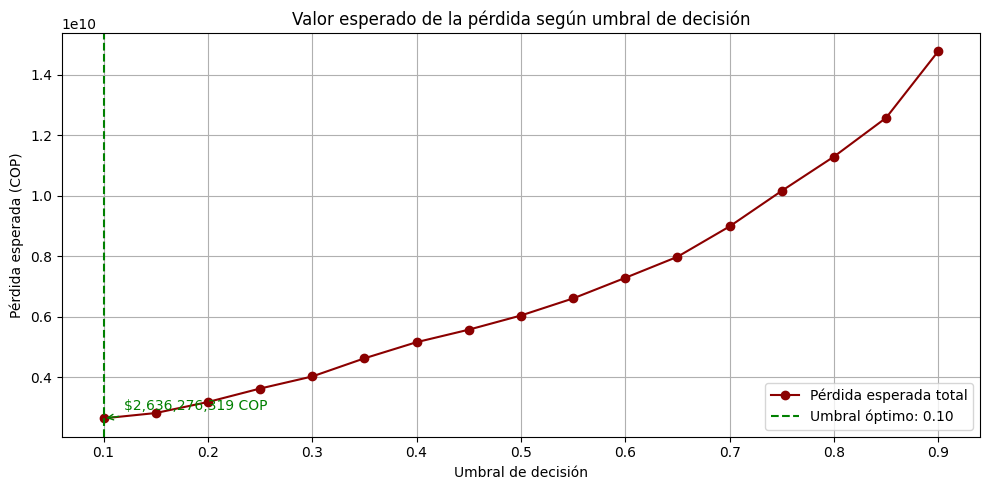

In [14]:
# Costos asignados
costo_FN = veinte_por_ciento  # ejemplo: 20% del valor del contrato
costo_FP = 100_000           # revisar innecesariamente

# Probabilidades base (no necesarias si y_test ya está balanceado)
P_adicion = (y_test == 1).mean()
P_no_adicion = (y_test == 0).mean()

umbrales = np.arange(0.1, 0.91, 0.05)
perdidas_esperadas = []

for umbral in umbrales:
    y_pred_custom = (y_proba_XG >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    # Valor esperado de la pérdida
    perdida = (fn * costo_FN) + (fp * costo_FP)
    perdidas_esperadas.append(perdida)

# Obtener umbral óptimo
min_idx = np.argmin(perdidas_esperadas)
mejor_umbral = umbrales[min_idx]
mejor_perdida = perdidas_esperadas[min_idx]

# Graficar resultado
plt.figure(figsize=(10, 5))
plt.plot(umbrales, perdidas_esperadas, marker='o', color='darkred', label='Pérdida esperada total')
plt.axvline(mejor_umbral, color='green', linestyle='--', label=f'Umbral óptimo: {mejor_umbral:.2f}')
plt.annotate(f'${mejor_perdida:,.0f} COP',
             xy=(mejor_umbral, mejor_perdida),
             xytext=(mejor_umbral+0.02, mejor_perdida*1.1),
             arrowprops=dict(arrowstyle="->", color='green'),
             fontsize=10,
             color='green')

plt.title('Valor esperado de la pérdida según umbral de decisión')
plt.xlabel('Umbral de decisión')
plt.ylabel('Pérdida esperada (COP)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Ejemplo 2

In [15]:
# Crear y entrenar el modelo XGBoost
model_XG2 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=13,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XG2.fit(X_train, y_train)

# Obtener predicciones como probabilidades
y_proba_XG2 = model_XG2.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.2
y_pred_XG_custom2 = (y_proba_XG2 >= umbral).astype(int)


# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_custom2, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_custom2))

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:53:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Evaluación del modelo XGBoost con umbral = 0.2

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       1.00      0.20      0.34     28350
     Adición       0.13      0.99      0.23      3486

    accuracy                           0.29     31836
   macro avg       0.56      0.60      0.29     31836
weighted avg       0.90      0.29      0.33     31836

Matriz de confusión:
[[ 5748 22602]
 [   26  3460]]


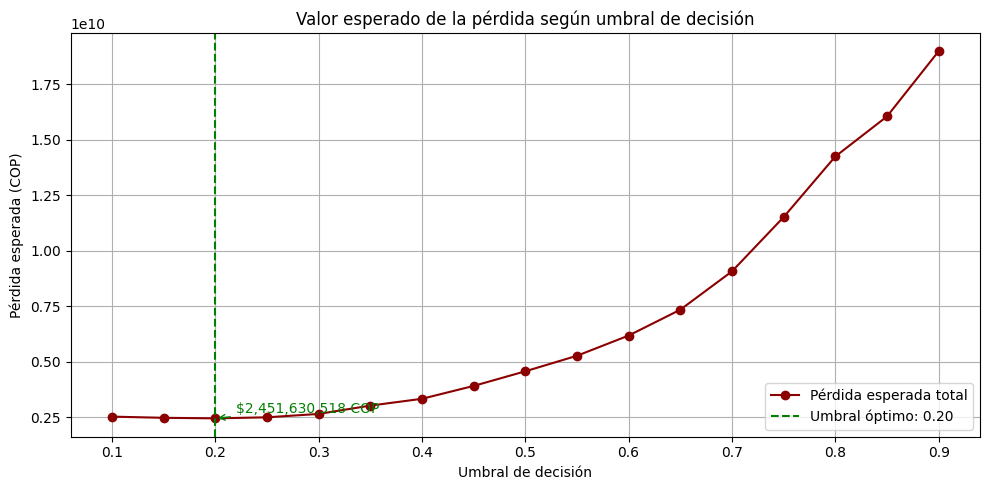

In [16]:
# Costos asignados
costo_FN = veinte_por_ciento  # ejemplo: 20% del valor del contrato
costo_FP = 100_000           # revisar innecesariamente

# Probabilidades base (no necesarias si y_test ya está balanceado)
P_adicion = (y_test == 1).mean()
P_no_adicion = (y_test == 0).mean()

umbrales = np.arange(0.1, 0.91, 0.05)
perdidas_esperadas2 = []

for umbral in umbrales:
    y_pred_custom2 = (y_proba_XG2 >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom2).ravel()

    # Valor esperado de la pérdida
    perdida = (fn * costo_FN) + (fp * costo_FP)
    perdidas_esperadas2.append(perdida)

# Obtener umbral óptimo
min_idx = np.argmin(perdidas_esperadas2)
mejor_umbral = umbrales[min_idx]
mejor_perdida = perdidas_esperadas2[min_idx]

# Graficar resultado
plt.figure(figsize=(10, 5))
plt.plot(umbrales, perdidas_esperadas2, marker='o', color='darkred', label='Pérdida esperada total')
plt.axvline(mejor_umbral, color='green', linestyle='--', label=f'Umbral óptimo: {mejor_umbral:.2f}')
plt.annotate(f'${mejor_perdida:,.0f} COP',
             xy=(mejor_umbral, mejor_perdida),
             xytext=(mejor_umbral+0.02, mejor_perdida*1.1),
             arrowprops=dict(arrowstyle="->", color='green'),
             fontsize=10,
             color='green')

plt.title('Valor esperado de la pérdida según umbral de decisión')
plt.xlabel('Umbral de decisión')
plt.ylabel('Pérdida esperada (COP)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Ejemplo 3

In [17]:
# Crear y entrenar el modelo XGBoost
model_XG3 = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=11,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XG3.fit(X_train, y_train)

# Obtener predicciones como probabilidades
y_proba_XG3 = model_XG3.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.2
y_pred_XG_custom3 = (y_proba_XG3 >= umbral).astype(int)


# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_custom3, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_custom3))

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:53:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Evaluación del modelo XGBoost con umbral = 0.2

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.99      0.28      0.44     28350
     Adición       0.14      0.98      0.25      3486

    accuracy                           0.36     31836
   macro avg       0.57      0.63      0.35     31836
weighted avg       0.90      0.36      0.42     31836

Matriz de confusión:
[[ 8036 20314]
 [   54  3432]]


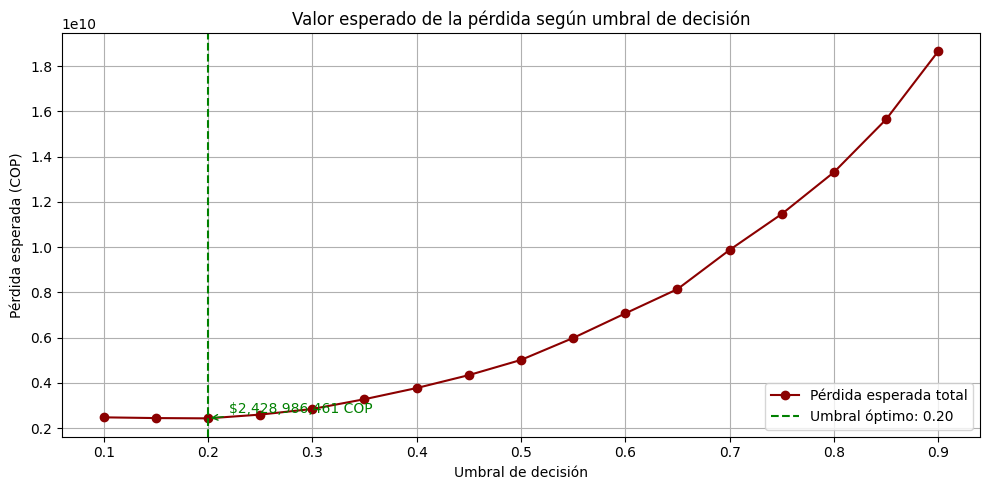

In [18]:
# Costos asignados
costo_FN = veinte_por_ciento  # ejemplo: 20% del valor del contrato
costo_FP = 100_000           # revisar innecesariamente

# Probabilidades base (no necesarias si y_test ya está balanceado)
P_adicion = (y_test == 1).mean()
P_no_adicion = (y_test == 0).mean()

umbrales = np.arange(0.1, 0.91, 0.05)
perdidas_esperadas3 = []

for umbral in umbrales:
    y_pred_custom3 = (y_proba_XG3 >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom3).ravel()

    # Valor esperado de la pérdida
    perdida = (fn * costo_FN) + (fp * costo_FP)
    perdidas_esperadas3.append(perdida)

# Obtener umbral óptimo
min_idx = np.argmin(perdidas_esperadas3)
mejor_umbral = umbrales[min_idx]
mejor_perdida = perdidas_esperadas3[min_idx]

# Graficar resultado
plt.figure(figsize=(10, 5))
plt.plot(umbrales, perdidas_esperadas3, marker='o', color='darkred', label='Pérdida esperada total')
plt.axvline(mejor_umbral, color='green', linestyle='--', label=f'Umbral óptimo: {mejor_umbral:.2f}')
plt.annotate(f'${mejor_perdida:,.0f} COP',
             xy=(mejor_umbral, mejor_perdida),
             xytext=(mejor_umbral+0.02, mejor_perdida*1.1),
             arrowprops=dict(arrowstyle="->", color='green'),
             fontsize=10,
             color='green')

plt.title('Valor esperado de la pérdida según umbral de decisión')
plt.xlabel('Umbral de decisión')
plt.ylabel('Pérdida esperada (COP)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Ejemplo 4

In [19]:
# Crear y entrenar el modelo XGBoost
model_XG4 = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.2,
    scale_pos_weight=10,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XG4.fit(X_train, y_train)

# Obtener predicciones como probabilidades
y_proba_XG4 = model_XG4.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.1
y_pred_XG_custom4 = (y_proba_XG4 >= umbral).astype(int)


# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_custom4, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_custom4))

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:53:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Evaluación del modelo XGBoost con umbral = 0.1

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.99      0.42      0.59     28350
     Adición       0.17      0.96      0.29      3486

    accuracy                           0.48     31836
   macro avg       0.58      0.69      0.44     31836
weighted avg       0.90      0.48      0.55     31836

Matriz de confusión:
[[11833 16517]
 [  134  3352]]


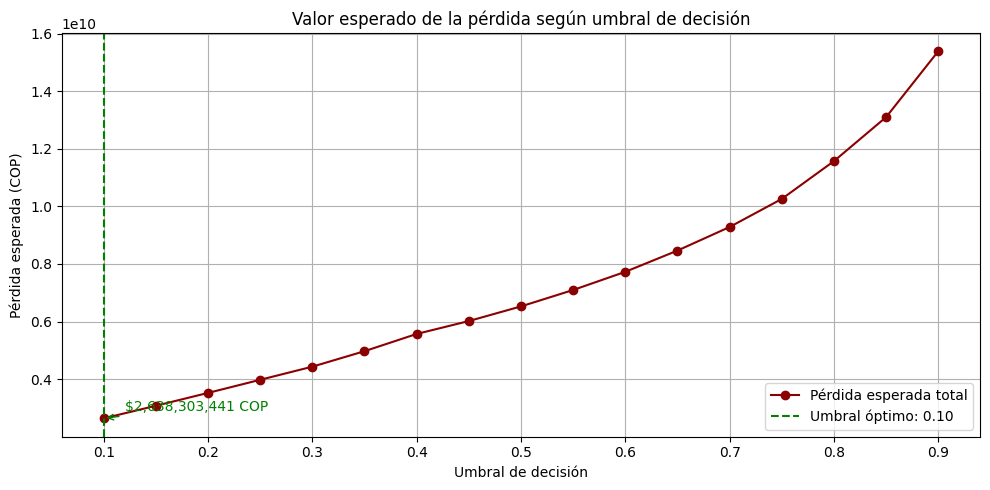

In [20]:
# Costos asignados
costo_FN = veinte_por_ciento  # ejemplo: 20% del valor del contrato
costo_FP = 100_000           # revisar innecesariamente

# Probabilidades base (no necesarias si y_test ya está balanceado)
P_adicion = (y_test == 1).mean()
P_no_adicion = (y_test == 0).mean()

umbrales = np.arange(0.1, 0.91, 0.05)
perdidas_esperadas4 = []

for umbral in umbrales:
    y_pred_custom4 = (y_proba_XG4 >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom4).ravel()

    # Valor esperado de la pérdida
    perdida = (fn * costo_FN) + (fp * costo_FP)
    perdidas_esperadas4.append(perdida)

# Obtener umbral óptimo
min_idx = np.argmin(perdidas_esperadas4)
mejor_umbral = umbrales[min_idx]
mejor_perdida = perdidas_esperadas4[min_idx]

# Graficar resultado
plt.figure(figsize=(10, 5))
plt.plot(umbrales, perdidas_esperadas4, marker='o', color='darkred', label='Pérdida esperada total')
plt.axvline(mejor_umbral, color='green', linestyle='--', label=f'Umbral óptimo: {mejor_umbral:.2f}')
plt.annotate(f'${mejor_perdida:,.0f} COP',
             xy=(mejor_umbral, mejor_perdida),
             xytext=(mejor_umbral+0.02, mejor_perdida*1.1),
             arrowprops=dict(arrowstyle="->", color='green'),
             fontsize=10,
             color='green')

plt.title('Valor esperado de la pérdida según umbral de decisión')
plt.xlabel('Umbral de decisión')
plt.ylabel('Pérdida esperada (COP)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Ejemplo 5

In [21]:
# Crear y entrenar el modelo XGBoost
model_XG5 = XGBClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.07,
    scale_pos_weight=11,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XG5.fit(X_train, y_train)

# Obtener predicciones como probabilidades
y_proba_XG5 = model_XG5.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.15
y_pred_XG_custom5 = (y_proba_XG5 >= umbral).astype(int)


# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_custom5, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_custom5))

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:53:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Evaluación del modelo XGBoost con umbral = 0.15

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       1.00      0.23      0.38     28350
     Adición       0.14      0.99      0.24      3486

    accuracy                           0.31     31836
   macro avg       0.57      0.61      0.31     31836
weighted avg       0.90      0.31      0.36     31836

Matriz de confusión:
[[ 6550 21800]
 [   29  3457]]


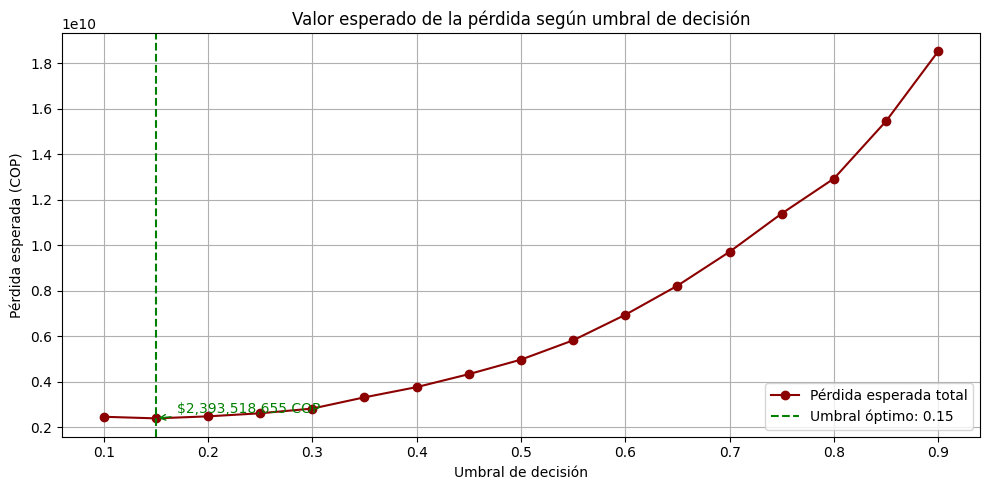

In [22]:
# Costos asignados
costo_FN = veinte_por_ciento  # ejemplo: 20% del valor del contrato
costo_FP = 100_000           # revisar innecesariamente

# Probabilidades base (no necesarias si y_test ya está balanceado)
P_adicion = (y_test == 1).mean()
P_no_adicion = (y_test == 0).mean()

umbrales = np.arange(0.1, 0.91, 0.05)
perdidas_esperadas5 = []

for umbral in umbrales:
    y_pred_custom5 = (y_proba_XG5 >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom5).ravel()

    # Valor esperado de la pérdida
    perdida = (fn * costo_FN) + (fp * costo_FP)
    perdidas_esperadas5.append(perdida)

# Obtener umbral óptimo
min_idx = np.argmin(perdidas_esperadas5)
mejor_umbral = umbrales[min_idx]
mejor_perdida = perdidas_esperadas5[min_idx]

# Graficar resultado
plt.figure(figsize=(10, 5))
plt.plot(umbrales, perdidas_esperadas5, marker='o', color='darkred', label='Pérdida esperada total')
plt.axvline(mejor_umbral, color='green', linestyle='--', label=f'Umbral óptimo: {mejor_umbral:.2f}')
plt.annotate(f'${mejor_perdida:,.0f} COP',
             xy=(mejor_umbral, mejor_perdida),
             xytext=(mejor_umbral+0.02, mejor_perdida*1.1),
             arrowprops=dict(arrowstyle="->", color='green'),
             fontsize=10,
             color='green')

plt.title('Valor esperado de la pérdida según umbral de decisión')
plt.xlabel('Umbral de decisión')
plt.ylabel('Pérdida esperada (COP)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Ejemplo 6

In [23]:
# Crear y entrenar el modelo XGBoost
model_XG6 = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    scale_pos_weight=11,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XG6.fit(X_train, y_train)

# Obtener predicciones como probabilidades
y_proba_XG6 = model_XG6.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.25
y_pred_XG_custom6 = (y_proba_XG6 >= umbral).astype(int)


# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_custom6, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_custom6))

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:53:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Evaluación del modelo XGBoost con umbral = 0.25

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.99      0.20      0.33     28350
     Adición       0.13      0.99      0.23      3486

    accuracy                           0.29     31836
   macro avg       0.56      0.59      0.28     31836
weighted avg       0.90      0.29      0.32     31836

Matriz de confusión:
[[ 5620 22730]
 [   29  3457]]


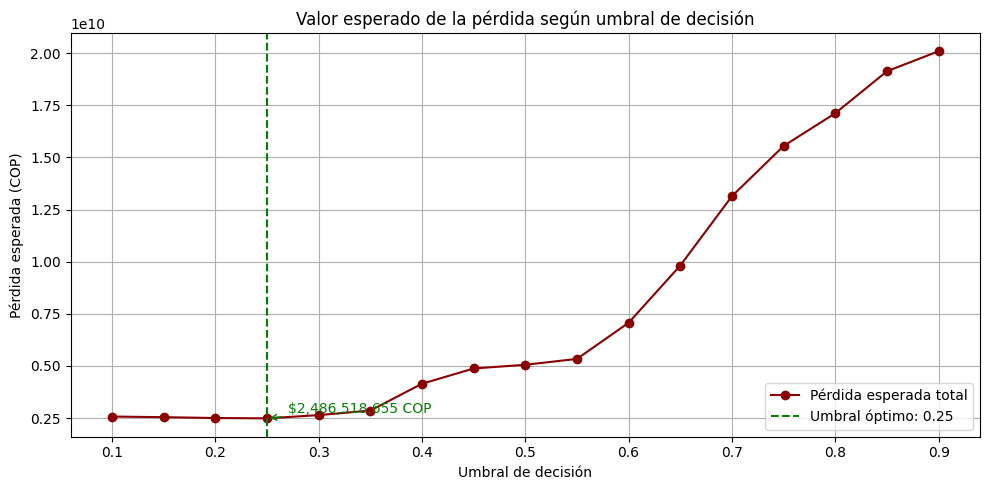

In [24]:
# Costos asignados
costo_FN = veinte_por_ciento  # ejemplo: 20% del valor del contrato
costo_FP = 100_000           # revisar innecesariamente

# Probabilidades base (no necesarias si y_test ya está balanceado)
P_adicion = (y_test == 1).mean()
P_no_adicion = (y_test == 0).mean()

umbrales = np.arange(0.1, 0.91, 0.05)
perdidas_esperadas6 = []

for umbral in umbrales:
    y_pred_custom6 = (y_proba_XG6 >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom6).ravel()

    # Valor esperado de la pérdida
    perdida = (fn * costo_FN) + (fp * costo_FP)
    perdidas_esperadas6.append(perdida)

# Obtener umbral óptimo
min_idx = np.argmin(perdidas_esperadas6)
mejor_umbral = umbrales[min_idx]
mejor_perdida = perdidas_esperadas6[min_idx]

# Graficar resultado
plt.figure(figsize=(10, 5))
plt.plot(umbrales, perdidas_esperadas6, marker='o', color='darkred', label='Pérdida esperada total')
plt.axvline(mejor_umbral, color='green', linestyle='--', label=f'Umbral óptimo: {mejor_umbral:.2f}')
plt.annotate(f'${mejor_perdida:,.0f} COP',
             xy=(mejor_umbral, mejor_perdida),
             xytext=(mejor_umbral+0.02, mejor_perdida*1.1),
             arrowprops=dict(arrowstyle="->", color='green'),
             fontsize=10,
             color='green')

plt.title('Valor esperado de la pérdida según umbral de decisión')
plt.xlabel('Umbral de decisión')
plt.ylabel('Pérdida esperada (COP)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

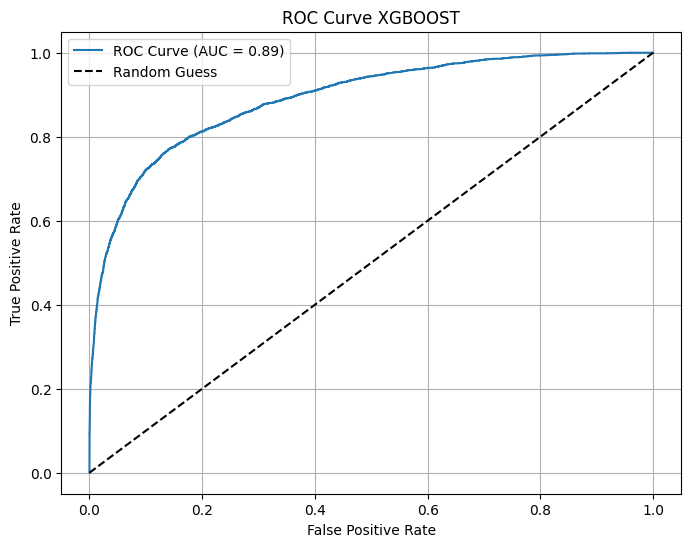

In [25]:
# Calcular las probabilidades predichas
y_pred_proba_XG = model_XG.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_XG)

# Calcular el AUC
auc_XG = roc_auc_score(y_test, y_pred_proba_XG)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_XG:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve XGBOOST')
plt.legend()
plt.grid()
plt.show()

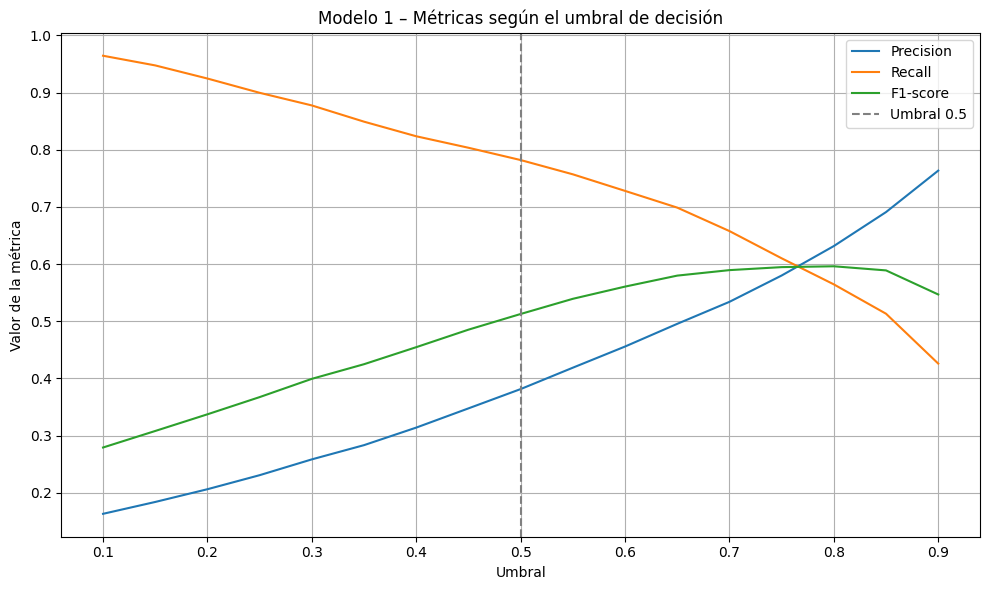

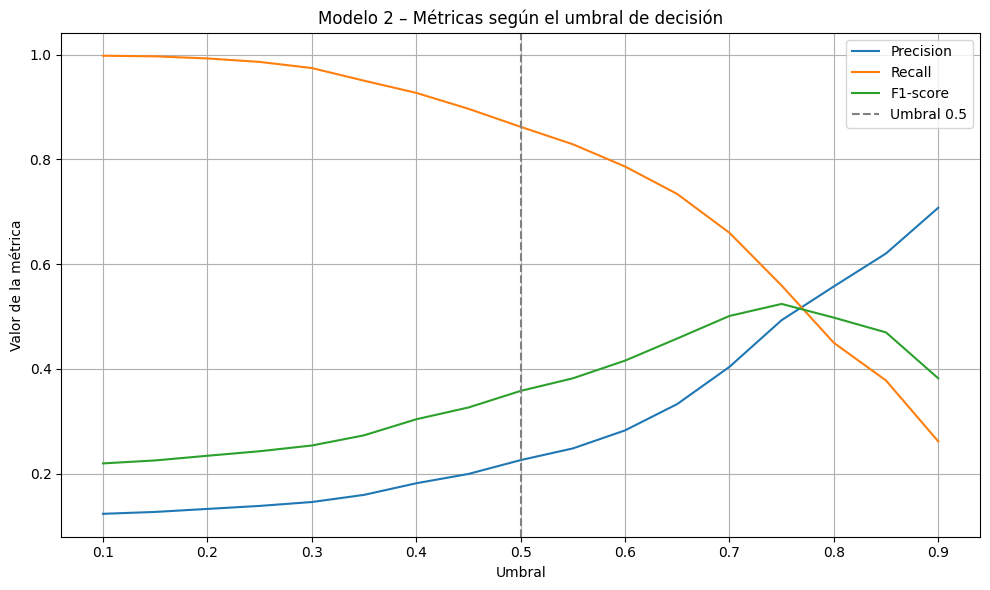

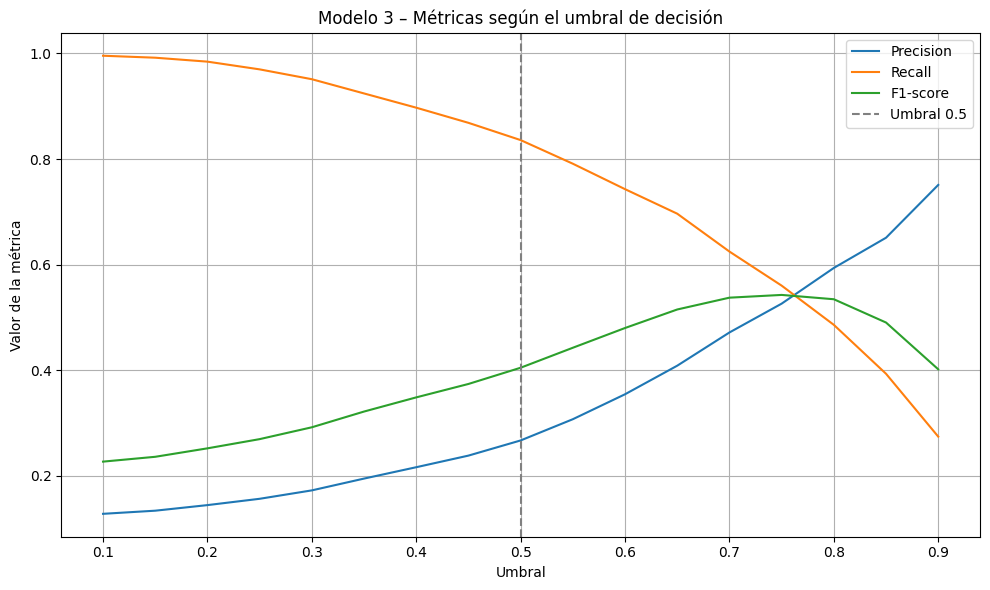

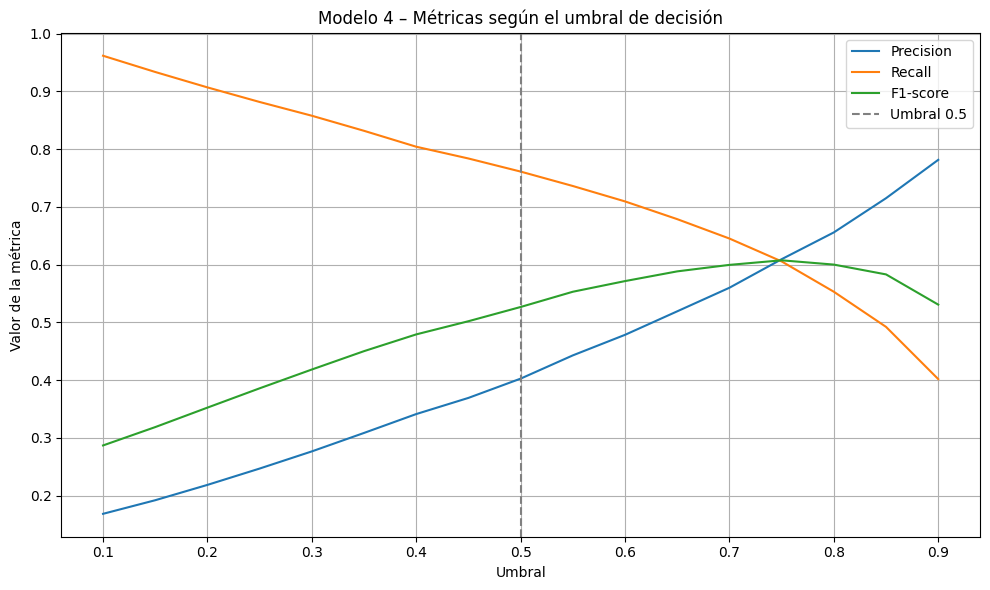

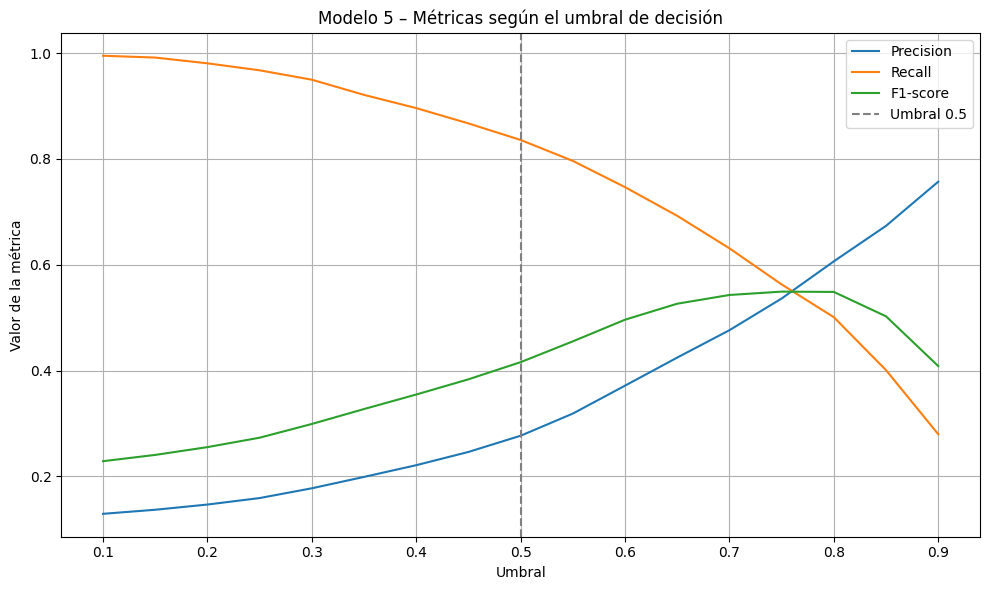

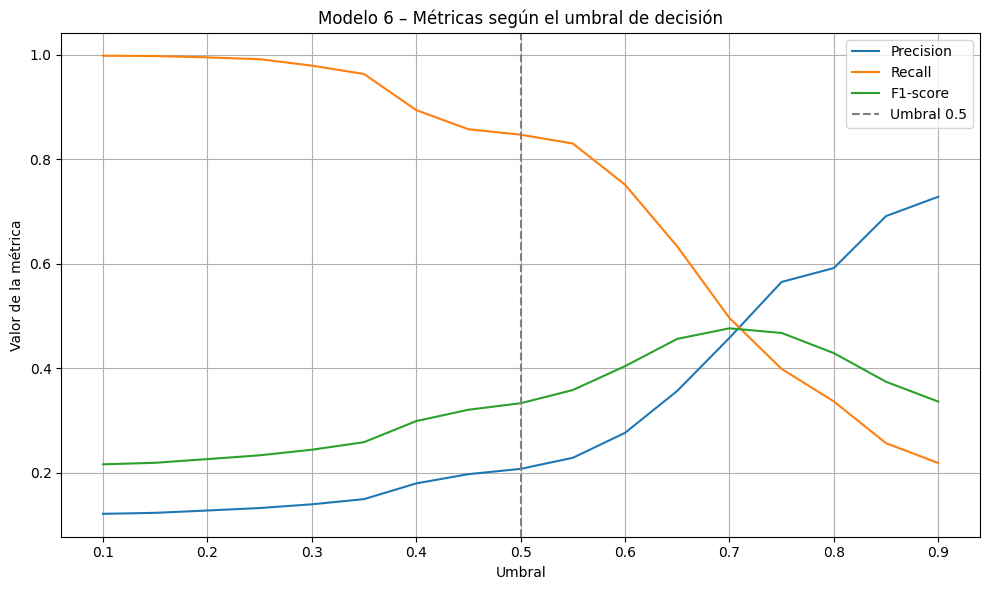

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Rango de umbrales
umbrales = np.arange(0.1, 0.95, 0.05)

# Diccionario con tus modelos ya entrenados
modelos = {
    "Modelo 1": model_XG,
    "Modelo 2": model_XG2,
    "Modelo 3": model_XG3,
    "Modelo 4": model_XG4,
    "Modelo 5": model_XG5,
    "Modelo 6": model_XG6
}

# Iterar por modelo
for nombre, modelo in modelos.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    precisions, recalls, f1s = [], [], []
    
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        precisions.append(precision_score(y_test, y_pred, pos_label=1))
        recalls.append(recall_score(y_test, y_pred, pos_label=1))
        f1s.append(f1_score(y_test, y_pred, pos_label=1))
    
    # Gráfico
    plt.figure(figsize=(10, 6))
    plt.plot(umbrales, precisions, label='Precision')
    plt.plot(umbrales, recalls, label='Recall')
    plt.plot(umbrales, f1s, label='F1-score')
    plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
    plt.title(f"{nombre} – Métricas según el umbral de decisión")
    plt.xlabel("Umbral")
    plt.ylabel("Valor de la métrica")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [27]:
print("Ejemplo 1",min(perdidas_esperadas))
print(classification_report(y_test, y_pred_XG_custom, target_names=['No Adición', 'Adición']))
print("Ejemplo 2",min(perdidas_esperadas2))
print(classification_report(y_test, y_pred_XG_custom2, target_names=['No Adición', 'Adición']))
print("Ejemplo 3",min(perdidas_esperadas3))
print(classification_report(y_test, y_pred_XG_custom3, target_names=['No Adición', 'Adición']))
print("Ejemplo 4",min(perdidas_esperadas4))
print(classification_report(y_test, y_pred_XG_custom4, target_names=['No Adición', 'Adición']))
print("Ejemplo 5",min(perdidas_esperadas5))
print(classification_report(y_test, y_pred_XG_custom5, target_names=['No Adición', 'Adición']))
print("Ejemplo 6",min(perdidas_esperadas6))
print(classification_report(y_test, y_pred_XG_custom6, target_names=['No Adición', 'Adición']))


Ejemplo 1 2636276318.8957114
              precision    recall  f1-score   support

  No Adición       0.99      0.39      0.56     28350
     Adición       0.16      0.96      0.28      3486

    accuracy                           0.45     31836
   macro avg       0.58      0.68      0.42     31836
weighted avg       0.90      0.45      0.53     31836

Ejemplo 2 2451630518.478133
              precision    recall  f1-score   support

  No Adición       1.00      0.20      0.34     28350
     Adición       0.13      0.99      0.23      3486

    accuracy                           0.29     31836
   macro avg       0.56      0.60      0.29     31836
weighted avg       0.90      0.29      0.33     31836

Ejemplo 3 2428986461.454584
              precision    recall  f1-score   support

  No Adición       0.99      0.28      0.44     28350
     Adición       0.14      0.98      0.25      3486

    accuracy                           0.36     31836
   macro avg       0.57      0.63      0.35

C:\Users\user\AppData\Local\Temp\ipykernel_8396\2346838723.py:54: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


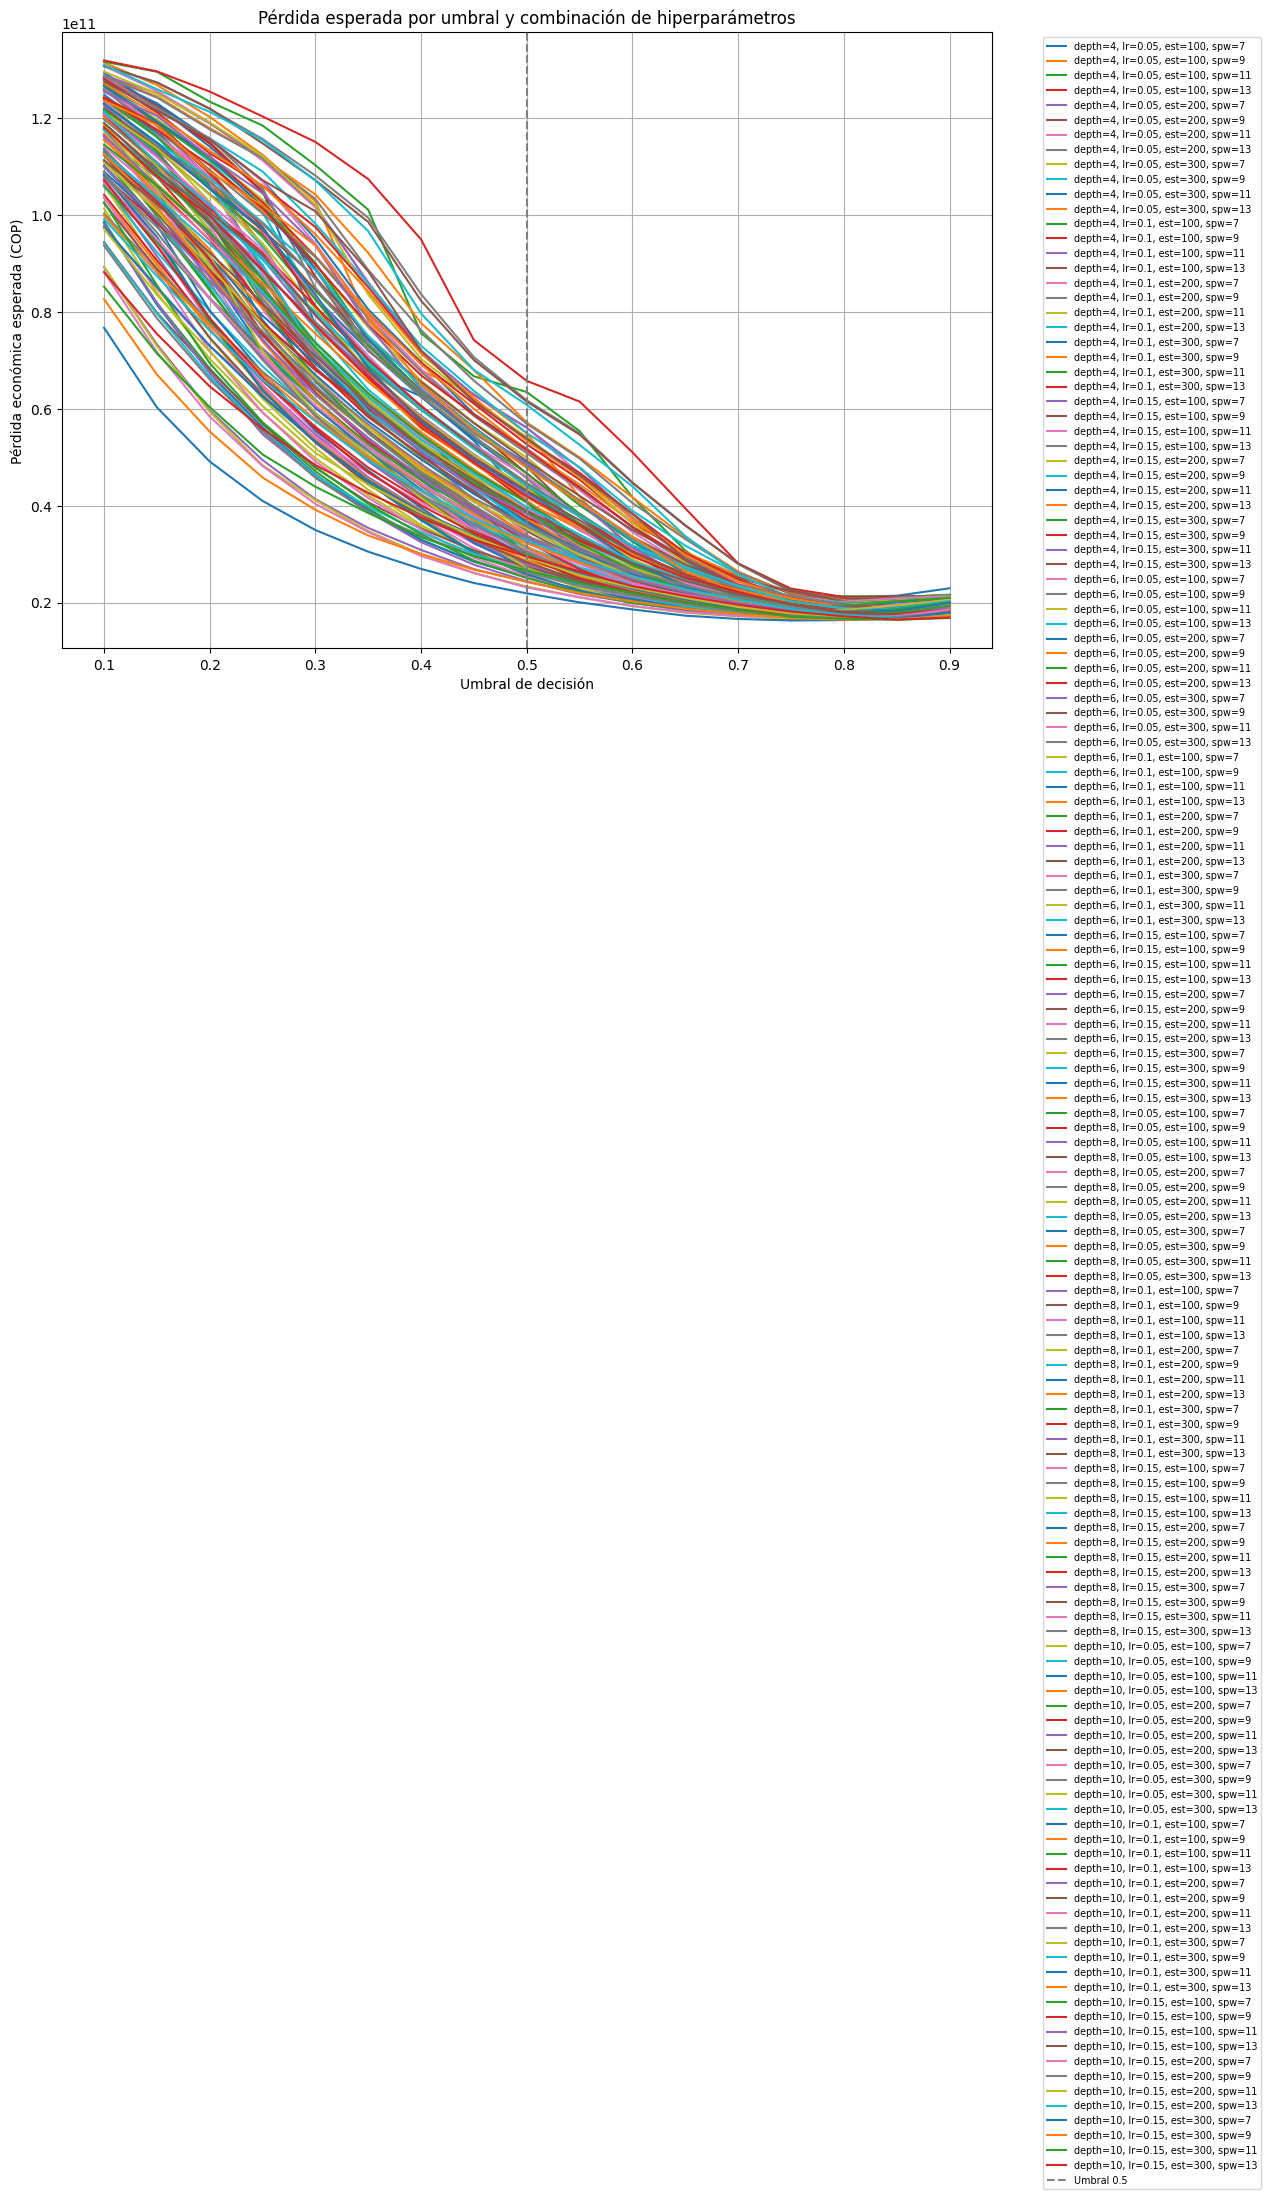

In [ ]:
# Hiperparámetros a combinar (ya sin subsample ni colsample_bytree)
max_depths = [4, 6, 8,10]
learning_rates = [0.05, 0.1, 0.15]
n_estimators_list = [100, 200,300]
scale_pos_weights = [7,9, 11, 13]

# Costos ajustables
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision

# Umbrales a explorar
umbrales = np.arange(0.05, 0.95, 0.05)
resultados = {}

# Generar combinaciones
combinaciones = list(product(max_depths, learning_rates, n_estimators_list, scale_pos_weights))

# Entrenar y calcular pérdidas
for max_depth, lr, n_estimators, spw in combinaciones:
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=lr,
        scale_pos_weight=spw,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    )

    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"depth={max_depth}, lr={lr}, est={n_estimators}, spw={spw}"
    resultados[etiqueta] = perdidas

# Graficar las curvas de pérdida
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación de hiperparámetros")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
# Encontrar la combinación y umbral con menor pérdida
mejor_combinacion = None
mejor_umbral = None
mejor_perdida = float('inf')

for nombre, perdidas in resultados.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida:
        mejor_perdida = perdidas[idx_min]
        mejor_combinacion = nombre
        mejor_umbral = umbrales[idx_min]

# Mostrar resultado óptimo
print("Mejor combinación encontrada:")
print(f"Parámetros: {mejor_combinacion}")
print(f"Umbral óptimo: {mejor_umbral:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida:,.0f} COP")


Mejor combinación encontrada:
Parámetros: depth=10, lr=0.15, est=300, spw=7
Umbral óptimo: 0.75
Pérdida mínima estimada: $16,318,991,135 COP


In [87]:
# Crear y entrenar el modelo XGBoost
model_XGdef = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.15,
    scale_pos_weight=13,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XGdef.fit(X_train, y_train)

# Obtener predicciones como probabilidades
y_proba_XGdef = model_XGdef.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.1
y_pred_XG_customedef = (y_proba_XGdef >= umbral).astype(int)


# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_customedef, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_customedef))

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = 100000    # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_XG_customedef).ravel()

# Calcular pérdida económica total
perdida_total = (fn * costo_FN) + (fp * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral}: ${perdida_total:,.0f} COP")
print(fn,fp)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:14:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Evaluación del modelo XGBoost con umbral = 0.1

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       1.00      0.25      0.40     28350
     Adición       0.14      0.99      0.24      3486

    accuracy                           0.33     31836
   macro avg       0.57      0.62      0.32     31836
weighted avg       0.90      0.33      0.38     31836

Matriz de confusión:
[[ 7027 21323]
 [   29  3457]]

Costo total estimado con umbral = 0.1: $2,345,818,655 COP
29 21323


In [103]:
Costoporcontrato=perdida_total/len(X_test)
Costoporcontrato

73684.46586334998

## Random Forest

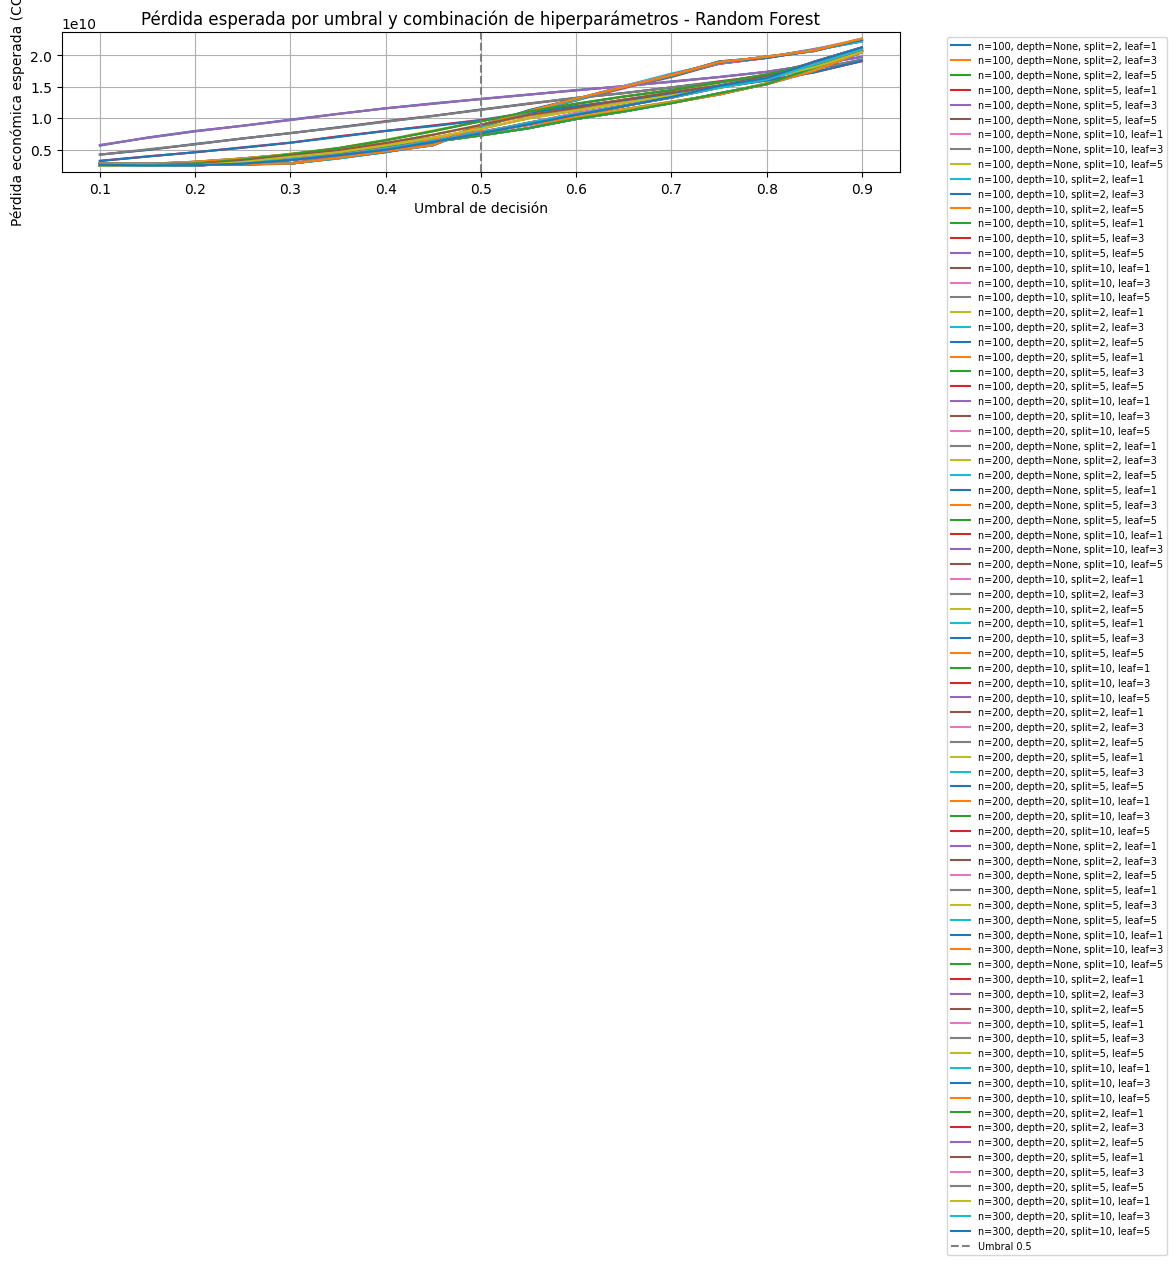

In [92]:

# Hiperparámetros a combinar
n_estimators_list = [100, 200,300]
max_depths = [None, 10, 20]
min_samples_splits = [2, 5,10]
min_samples_leafs = [1, 3,5]

# Costos
costo_FN = veinte_por_ciento  # Falso negativo (no detectar una adición)
costo_FP = 100000  # Falso positivo (revisar contrato innecesario)

# Umbrales
umbrales = np.arange(0.1, 0.95, 0.05)
resultados_rf = {}

# Todas las combinaciones posibles
combinaciones = list(product(n_estimators_list, max_depths, min_samples_splits, min_samples_leafs))

# Evaluación por combinación
for n_est, max_d, min_split, min_leaf in combinaciones:
    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"n={n_est}, depth={max_d}, split={min_split}, leaf={min_leaf}"
    resultados_rf[etiqueta] = perdidas

# Graficar resultados
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados_rf.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación de hiperparámetros - Random Forest")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [94]:
# Encontrar la combinación y umbral con menor pérdida en RF
mejor_combinacion_rf = None
mejor_umbral_rf = None
mejor_perdida_rf = float('inf')

for nombre, perdidas in resultados_rf.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida_rf:
        mejor_perdida_rf = perdidas[idx_min]
        mejor_combinacion_rf = nombre
        mejor_umbral_rf = umbrales[idx_min]

# Mostrar resultado óptimo
print("\nMejor combinación encontrada (Random Forest):")
print(f"Parámetros: {mejor_combinacion_rf}")
print(f"Umbral óptimo: {mejor_umbral_rf:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_rf:,.0f} COP")



Mejor combinación encontrada (Random Forest):
Parámetros: n=300, depth=None, split=2, leaf=3
Umbral óptimo: 0.10
Pérdida mínima estimada: $2,408,437,310 COP


In [98]:
# Crear y entrenar el modelo Random Forest
model_RF = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42)
# Entrenar el modelo
model_RF.fit(X_train, y_train)

# Hacer predicciones
y_pred_RF = model_RF.predict(X_test)

# Obtener probabilidades
y_proba_RF = model_RF.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbralrf = 0.1  # por ejemplo
y_pred_RF_custom = (y_proba_RF >= umbralrf).astype(int)

print(f"\nEvaluación con umbral = {umbralrf}\n")
print(classification_report(y_test, y_pred_RF_custom, target_names=['No Adición', 'Adición']))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_RF_custom))

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = 100000    # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tnrf, fprf, fnrf, tprf = confusion_matrix(y_test, y_pred_RF_custom).ravel()

# Calcular pérdida económica total
perdida_totalrf = (fnrf * costo_FN) + (fprf* costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbralrf}: ${perdida_totalrf:,.0f} COP")
print(fnrf,fprf)



Evaluación con umbral = 0.1

              precision    recall  f1-score   support

  No Adición       0.99      0.30      0.46     28350
     Adición       0.15      0.98      0.26      3486

    accuracy                           0.38     31836
   macro avg       0.57      0.64      0.36     31836
weighted avg       0.90      0.38      0.44     31836

Matriz de confusión:
[[ 8536 19814]
 [   58  3428]]

Costo total estimado con umbral = 0.1: $2,408,437,310 COP
58 19814


In [ ]:
Costoporcontratorf=perdida_totalrf/len(X_test)
Costoporcontratorf

75651.37927036123

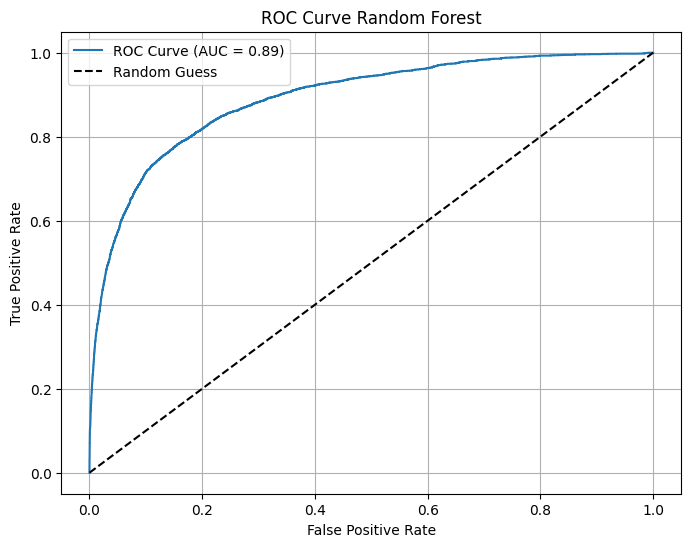

In [104]:
# Calcular las probabilidades predichas
y_pred_proba_RF = model_RF.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_RF)

# Calcular el AUC
auc_RF = roc_auc_score(y_test, y_pred_proba_RF)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_RF:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Random Forest')
plt.legend()
plt.grid()
plt.show()

## Modelo LGB

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 14468, number of negative: 112877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008388 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1888
[LightGBM] [Info] Number of data points in the train set: 127345, number of used features: 307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

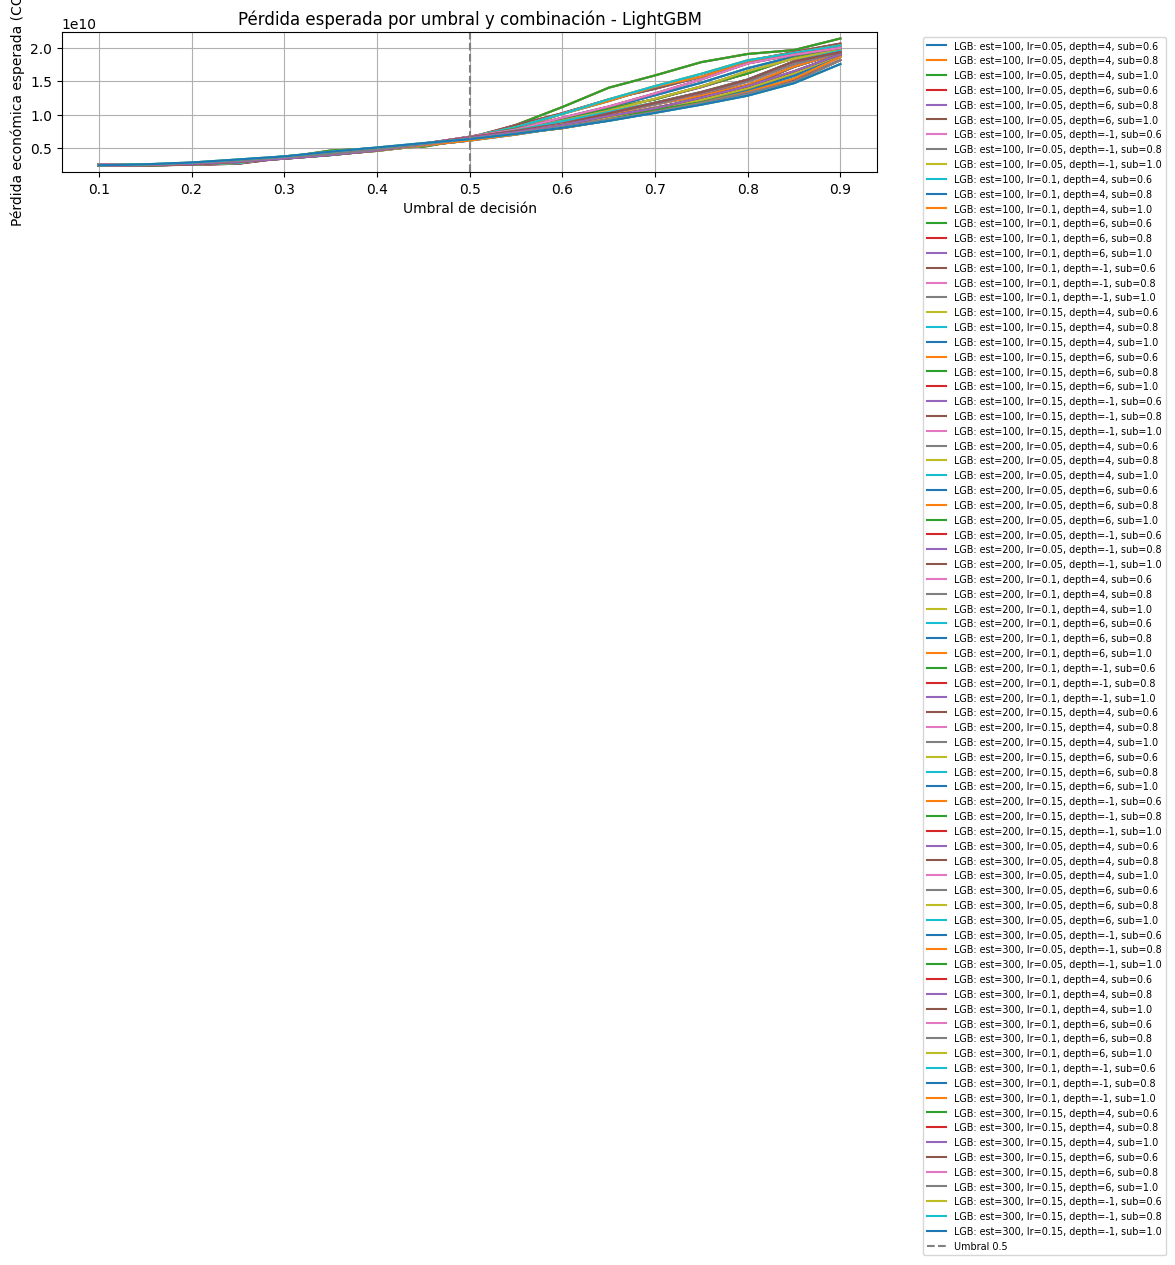

In [108]:
# Hiperparámetros a probar
n_estimators_list = [100, 200,300]
learning_rates = [0.05, 0.1,0.15]
max_depths = [4, 6, -1]
subsamples = [0.6, 0.8, 1.0]

# Costos
costo_FN = veinte_por_ciento
costo_FP = 100_000

# Umbrales
umbrales = np.arange(0.1, 0.95, 0.05)
resultados_lgb = {}

# Todas las combinaciones posibles
combinaciones = list(product(n_estimators_list, learning_rates, max_depths, subsamples))

# Evaluar cada combinación
for n_est, lr, max_d, subsample in combinaciones:
    model = lgb.LGBMClassifier(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=max_d,
        subsample=subsample,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"LGB: est={n_est}, lr={lr}, depth={max_d}, sub={subsample}"
    resultados_lgb[etiqueta] = perdidas

# Graficar
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados_lgb.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación - LightGBM")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [109]:
# Encontrar la combinación y umbral con menor pérdida en LightGBM
mejor_combinacion_lgb = None
mejor_umbral_lgb = None
mejor_perdida_lgb = float('inf')

for nombre, perdidas in resultados_lgb.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida_lgb:
        mejor_perdida_lgb = perdidas[idx_min]
        mejor_combinacion_lgb = nombre
        mejor_umbral_lgb = umbrales[idx_min]

# Mostrar resultado óptimo
print("\nMejor combinación encontrada (LightGBM):")
print(f"Parámetros: {mejor_combinacion_lgb}")
print(f"Umbral óptimo: {mejor_umbral_lgb:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_lgb:,.0f} COP")



Mejor combinación encontrada (LightGBM):
Parámetros: LGB: est=200, lr=0.15, depth=-1, sub=0.6
Umbral óptimo: 0.10
Pérdida mínima estimada: $2,310,008,490 COP


In [112]:
# Crear y entrenar el modelo LightGBM
model_LGB = lgb.LGBMClassifier(
    n_estimators=200,          # Número de árboles
    max_depth=-1,              # Sin límite de profundidad
    learning_rate=0.15,        # Tasa de aprendizaje
    subsample=0.6,             # Proporción de datos para cada árbol
    colsample_bytree=0.8,      # Proporción de características para cada árbol
    class_weight='balanced',   # Manejo de clases desbalanceadas
    random_state=42            # Para reproducibilidad
)

# Entrenar el modelo
model_LGB.fit(X_train, y_train)

# Definir el umbral deseado
umbral_lgb = 0.1  # Puedes cambiarlo según lo que quieras probar

# Predecir probabilidades
y_proba_LGB = model_LGB.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
y_pred_LGB_custom = (y_proba_LGB >= umbral_lgb).astype(int)

# Evaluación
print(f"\nEvaluación del modelo LightGBM con umbral = {umbral_lgb}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_LGB_custom, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_LGB = confusion_matrix(y_test, y_pred_LGB_custom)
print("\nMatriz de confusión:")
print(conf_matrix_LGB)

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = 100000               # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tnlgb, fplgb, fnlgb, tplgb = conf_matrix_LGB.ravel()

# Calcular pérdida económica total
perdida_total_lgb = (fnlgb * costo_FN) + (fplgb * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral_lgb}: ${perdida_total_lgb:,.0f} COP")
print(f"FN = {fnlgb}, FP = {fplgb}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 14468, number of negative: 112877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1888
[LightGBM] [Info] Number of data points in the train set: 127345, number of used features: 307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

Evaluación del modelo LightGBM con umbral = 0.1

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       1.00      0.29      0.45     28350
     Adición       0.15      0.99      0.25      3486

    accuracy                           0.37     31836
   macro avg       0.57      0.64      0.35     31836
weighted avg 

In [111]:
Costoporcontratolgb=perdida_total_lgb/len(X_test)
Costoporcontratolgb

72559.63343279177

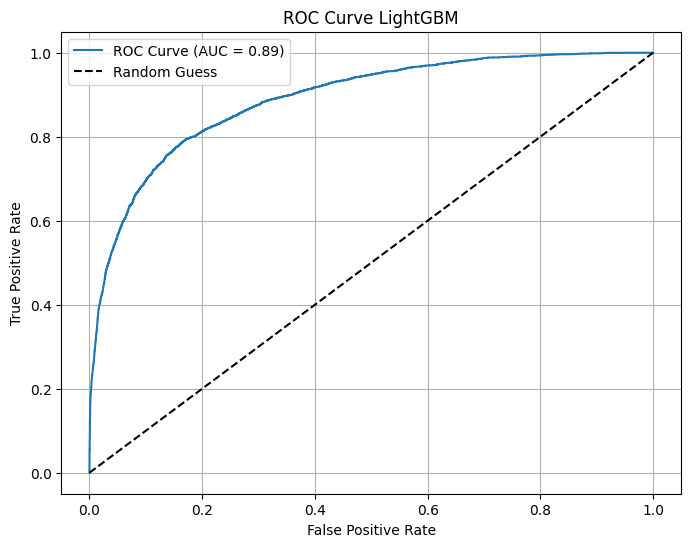

In [113]:
# Calcular las probabilidades predichas
y_pred_proba_LGB = model_LGB.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_LGB)

# Calcular el AUC
auc_LGB = roc_auc_score(y_test, y_pred_proba_LGB)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_LGB:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve LightGBM')
plt.legend()
plt.grid()
plt.show()

### Redes neuronales

In [120]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear el modelo de red neuronal
model_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Salida binaria
])

# Compilar el modelo
model_nn.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Entrenar el modelo
history = model_nn.fit(X_train_scaled, y_train, 
                       validation_data=(X_test_scaled, y_test),
                       epochs=50, 
                       batch_size=32, 
                       verbose=1)

# Evaluar el modelo
loss, accuracy = model_nn.evaluate(X_test_scaled, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

# Predecir probabilidades
y_proba_nn = model_nn.predict(X_test_scaled)

# Aplicar un umbral personalizado
umbral_nn = 0.1
y_pred_nn_custom = (y_proba_nn >= umbral_nn).astype(int)

# Evaluación
print(f"\nEvaluación del modelo de red neuronal con umbral = {umbral_nn}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_nn_custom, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn_custom)
print("\nMatriz de confusión:")
print(conf_matrix_nn)

# Calcular pérdida económica total
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = 100000               # Revisar innecesariamente un contrato
tn_nn, fp_nn, fn_nn, tp_nn = conf_matrix_nn.ravel()
perdida_total_nn = (fn_nn * costo_FN) + (fp_nn * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral_nn}: ${perdida_total_nn:,.0f} COP")

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8941 - loss: 0.3058 - val_accuracy: 0.9085 - val_loss: 0.2559
Epoch 2/50
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9031 - loss: 0.2675 - val_accuracy: 0.9112 - val_loss: 0.2468
Epoch 3/50
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9051 - loss: 0.2565 - val_accuracy: 0.9121 - val_loss: 0.2485
Epoch 4/50
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9075 - loss: 0.2511 - val_accuracy: 0.9123 - val_loss: 0.2435
Epoch 5/50
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9080 - loss: 0.2493 - val_accuracy: 0.9130 - val_loss: 0.2377
Epoch 6/50
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9086 - loss: 0.2463 - val_accuracy: 0.9097 - val_loss: 0.2384
Epoch 7/50
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9092 - loss: 0.2425 - val_accuracy: 0.9142 - val_loss: 0.2344
Epoch 8/50
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9091 - loss: 0.2412 - 

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 543us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 507us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 520us/step


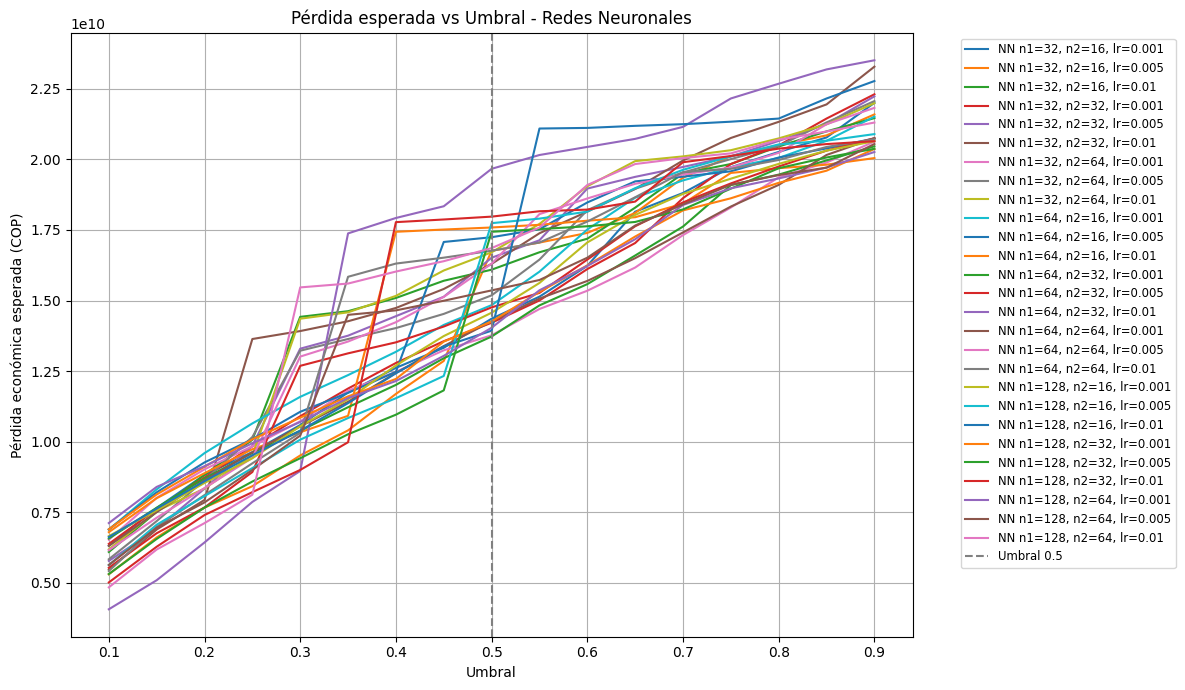

In [122]:


# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hiperparámetros a combinar
n_neurons_1_list = [32, 64,128]
n_neurons_2_list = [16, 32,64]
learning_rates = [0.001, 0.005,0.01]
epochs = 50
batch_size = 64
umbrales = np.arange(0.1, 0.95, 0.05)

# Costos
costo_FN = veinte_por_ciento
costo_FP = 100_000

# Guardar resultados
resultados_nn = {}

# Combinaciones
combinaciones = list(product(n_neurons_1_list, n_neurons_2_list, learning_rates))

for n1, n2, lr in combinaciones:
    model = Sequential([
        Dense(n1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(n2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    model.fit(X_train_scaled, y_train,
              validation_data=(X_test_scaled, y_test),
              epochs=epochs,
              batch_size=batch_size,
              verbose=0)
    
    y_proba = model.predict(X_test_scaled)
    perdidas = []
    
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    nombre = f"NN n1={n1}, n2={n2}, lr={lr}"
    resultados_nn[nombre] = perdidas

# Graficar pérdidas
plt.figure(figsize=(12, 7))
for nombre, perdidas in resultados_nn.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada vs Umbral - Redes Neuronales")
plt.xlabel("Umbral")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [123]:
# Encontrar la combinación y umbral con menor pérdida en la red neuronal
mejor_combinacion_nn = None
mejor_umbral_nn = None
mejor_perdida_nn = float('inf')

for nombre, perdidas in resultados_nn.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida_nn:
        mejor_perdida_nn = perdidas[idx_min]
        mejor_combinacion_nn = nombre
        mejor_umbral_nn = umbrales[idx_min]

# Mostrar resultado óptimo
print("\nMejor combinación encontrada (Red Neuronal):")
print(f"Parámetros: {mejor_combinacion_nn}")
print(f"Umbral óptimo: {mejor_umbral_nn:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_nn:,.0f} COP")



Mejor combinación encontrada (Red Neuronal):
Parámetros: NN n1=64, n2=32, lr=0.01
Umbral óptimo: 0.10
Pérdida mínima estimada: $4,065,847,612 COP


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Parámetros
n1 = 64
n2 = 32
learning_rate = 0.01
epochs = 50
batch_size = 64
umbral_nn = 0.1  # Umbral para clasificación

# Crear el modelo
model_nn = Sequential([
    Dense(n1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(n2, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Salida binaria
])

# Compilar el modelo
model_nn.compile(optimizer=Adam(learning_rate=learning_rate),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Entrenar el modelo
history = model_nn.fit(X_train_scaled, y_train,
                       validation_data=(X_test_scaled, y_test),
                       epochs=epochs,
                       batch_size=batch_size,
                       verbose=1)

# Evaluar el modelo
loss, accuracy = model_nn.evaluate(X_test_scaled, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

# Predecir probabilidades
y_proba_nn = model_nn.predict(X_test_scaled)

# Aplicar el umbral personalizado
y_pred_nn_custom = (y_proba_nn >= umbral_nn).astype(int)

# Evaluación
print(f"\nEvaluación del modelo de red neuronal con umbral = {umbral_nn}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_nn_custom, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn_custom)
print("\nMatriz de confusión:")
print(conf_matrix_nn)

# Calcular pérdida económica total
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = 100000               # Revisar innecesariamente un contrato
tn_nn, fp_nn, fn_nn, tp_nn = conf_matrix_nn.ravel()
perdida_total_nn = (fn_nn * costo_FN) + (fp_nn * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral_nn}: ${perdida_total_nn:,.0f} COP")

Epoch 1/50


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1990/1990 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8988 - loss: 0.2897 - val_accuracy: 0.9081 - val_loss: 0.2602
Epoch 2/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9043 - loss: 0.2629 - val_accuracy: 0.9100 - val_loss: 0.2686
Epoch 3/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9077 - loss: 0.2562 - val_accuracy: 0.9108 - val_loss: 0.2486
Epoch 4/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9077 - loss: 0.2509 - val_accuracy: 0.9111 - val_loss: 0.2480
Epoch 5/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9092 - loss: 0.2456 - val_accuracy: 0.9089 - val_loss: 0.2456
Epoch 6/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9092 - loss: 0.2443 - val_accuracy: 0.9125 - val_loss: 0.2427
Epoch 7/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9088 - loss: 0.2440 - val_accuracy: 0.9121 - val_loss: 0.2461
Epoch 8/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9110 - loss: 0.2392 - val_accurac

In [128]:
Costoporcontratonn=perdida_total_nn/len(X_test)
Costoporcontratonn

140212.87586804215